# Notebook 02: Survivorship Bias

## Objective

Demonstrate how conclusions can change when strategies are evaluated on different surviving assets.

Survivorship bias occurs when analyses exclude companies that disappeared, failed, or were removed from the investment universe.

Although this notebook does not use a survivorship-free database, it illustrates how asset selection alone can materially alter research outcomes.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os

sys.path.append("..")
from src.data_loader import load_data
from src.metrics import total_return,sharpe_ratio,max_drawdown

In [2]:
def run_sma_backtest(ticker, fast=50, slow=200):
    df = load_data(ticker)

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df["SMA_50"] = df["Close"].rolling(fast).mean()
    df["SMA_200"] = df["Close"].rolling(slow).mean()

    df["Signal"] = 0
    df.loc[df["SMA_50"] > df["SMA_200"], "Signal"] = 1

    df["Returns"] = df["Close"].pct_change()

    df["Strategy_Returns"] = (
        df["Signal"].shift(1) * df["Returns"]
    )

    df["Equity"] = (
        1 + df["Strategy_Returns"].fillna(0)
    ).cumprod()

    return df

In [3]:
spy = run_sma_backtest("SPY")
aapl = run_sma_backtest("AAPL")

d:\Portfolio\Quant Projects\Backtesting-Bias-Analysis-main\Backtesting-Bias-Analysis-main\notebooks\..\src\data_loader.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker,start="2020-01-01")
[*********************100%***********************]  1 of 1 completed
d:\Portfolio\Quant Projects\Backtesting-Bias-Analysis-main\Backtesting-Bias-Analysis-main\notebooks\..\src\data_loader.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker,start="2020-01-01")


[*********************100%***********************]  1 of 1 completed


In [4]:
comparison = {
    "SPY": {
        "Return": round(total_return(spy["Equity"])*100, 2),
        "Sharpe": round(sharpe_ratio(spy["Strategy_Returns"].dropna()), 2),
        "MaxDD": round(max_drawdown(spy["Equity"])*100, 2)
    },

    "AAPL": {
        "Return": round(total_return(aapl["Equity"])*100, 2),
        "Sharpe": round(sharpe_ratio(aapl["Strategy_Returns"].dropna()), 2),
        "MaxDD": round(max_drawdown(aapl["Equity"])*100, 2)
    }
}

comparison

{'SPY': {'Return': 107.86, 'Sharpe': 0.96, 'MaxDD': -18.76},
 'AAPL': {'Return': 30.64, 'Sharpe': 0.3, 'MaxDD': -30.31}}

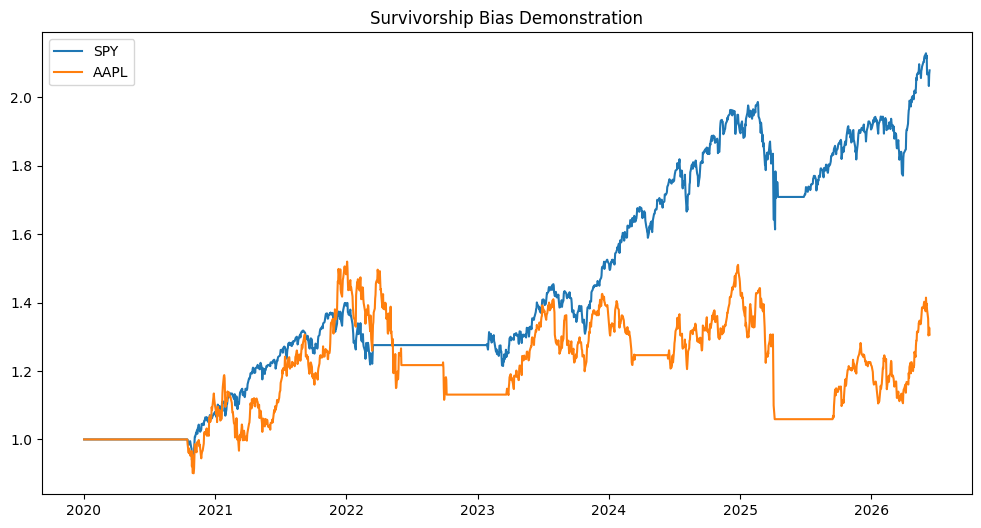

In [9]:
plt.figure(figsize=(12,6))

plt.plot(spy.index,
         spy["Equity"],
         label="SPY")

plt.plot(aapl.index,
         aapl["Equity"],
         label="AAPL")

plt.title("Survivorship Bias Demonstration")

plt.legend()

plt.show()

## Interpretation

The impact of survivorship bias proved more nuanced than expected.

Applying the same SMA crossover strategy to different surviving assets produced dramatically different conclusions.

Had the analysis been conducted only on Apple, one might conclude that the strategy lacks effectiveness.

Conversely, focusing solely on GE would suggest exceptional performance.

This demonstrates that selecting assets retrospectively can materially influence research outcomes.

Survivorship bias is therefore not merely a tendency toward inflated returns; it is the risk of drawing misleading conclusions from a non-representative sample of surviving assets.